##### =================== STAGE 04 FEATURE ENGINEERING ======================== #####

In [3]:
import numpy as np
import pandas as pd
import os

In [4]:
# LOAD DATA FROM DATA/CLEANED FOLDER
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "cleaned", "energy_cleaned_data.csv")
df = pd.read_csv(data_path)
df.head()

,customer_id,region,meter_id,timestamp_utc,kwh,tariff_plan,is_smart_meter,outage_minutes_last_24h,bill_amount_eur,complaint_flag
0,201,East,MID201,2026-01-01 00:00:00,2.831160,fixed,1,15,0.509609,0
1,201,East,MID201,2026-01-01 01:00:00,1.939790,fixed,1,10,0.349162,0
2,201,East,MID201,2026-01-01 02:00:00,1.823063,fixed,1,11,0.328151,0
3,201,East,MID201,2026-01-01 03:00:00,0.629419,fixed,1,7,0.113295,0
4,201,South,MID201,2026-01-01 04:00:00,1.423434,fixed,1,10,0.256218,0


In [5]:
# FEATURE ENGINEERING FROM THE TIMESTAMP COLUMN BEING THE DATETIME INDEX
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

In [12]:
df["timestamp_utc"].dt.date

0         2026-01-01
1         2026-01-01
2         2026-01-01
3         2026-01-01
4         2026-01-01
             ...    
144005    2026-02-22
144006    2026-01-13
144007    2026-02-21
144008    2026-02-04
144009    2026-01-29
Name: timestamp_utc, Length: 144010, dtype: object

In [13]:
df["timestamp_utc"].dt.hour

0          0
1          1
2          2
3          3
4          4
          ..
144005    14
144006    11
144007    22
144008     3
144009    15
Name: timestamp_utc, Length: 144010, dtype: int32

In [14]:
df["timestamp_utc"].dt.year

0         2026
1         2026
2         2026
3         2026
4         2026
          ... 
144005    2026
144006    2026
144007    2026
144008    2026
144009    2026
Name: timestamp_utc, Length: 144010, dtype: int32

In [17]:
df["timestamp_utc"].dt.month

0         1
1         1
2         1
3         1
4         1
         ..
144005    2
144006    1
144007    2
144008    2
144009    1
Name: timestamp_utc, Length: 144010, dtype: int32

In [18]:
df["timestamp_utc"].dt.day_of_week

0         3
1         3
2         3
3         3
4         3
         ..
144005    6
144006    1
144007    5
144008    2
144009    3
Name: timestamp_utc, Length: 144010, dtype: int32

In [20]:
df["timestamp_utc"].dt.day_name()

0          Thursday
1          Thursday
2          Thursday
3          Thursday
4          Thursday
            ...    
144005       Sunday
144006      Tuesday
144007     Saturday
144008    Wednesday
144009     Thursday
Name: timestamp_utc, Length: 144010, dtype: str

In [24]:
def engineered_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
    df["date"] = df["timestamp_utc"].dt.date
    df["hour"] = df["timestamp_utc"].dt.hour
    df["year"] = df["timestamp_utc"].dt.year
    df["month"] = df["timestamp_utc"].dt.month
    df["day_name"] = df["timestamp_utc"].dt.day_name()
    df["is_peak_hour"] = df["hour"].apply(lambda x: 1 if x in [17, 18, 19, 20, 21, 22] else 0)
    df.drop(columns=['timestamp_utc'], inplace=True)
    return df


In [25]:
df = engineered_time_features(df)
df.head()

,customer_id,region,meter_id,kwh,tariff_plan,is_smart_meter,outage_minutes_last_24h,bill_amount_eur,complaint_flag,date,hour,year,month,day_name,is_peak_hour
0,201,East,MID201,2.831160,fixed,1,15,0.509609,0,2026-01-01,0,2026,1,Thursday,0
1,201,East,MID201,1.939790,fixed,1,10,0.349162,0,2026-01-01,1,2026,1,Thursday,0
2,201,East,MID201,1.823063,fixed,1,11,0.328151,0,2026-01-01,2,2026,1,Thursday,0
3,201,East,MID201,0.629419,fixed,1,7,0.113295,0,2026-01-01,3,2026,1,Thursday,0
4,201,South,MID201,1.423434,fixed,1,10,0.256218,0,2026-01-01,4,2026,1,Thursday,0


In [26]:
df.columns

Index(['customer_id', 'region', 'meter_id', 'kwh', 'tariff_plan',
       'is_smart_meter', 'outage_minutes_last_24h', 'bill_amount_eur',
       'complaint_flag', 'date', 'hour', 'year', 'month', 'day_name',
       'is_peak_hour'],
      dtype='str')

<Axes: xlabel='hour'>

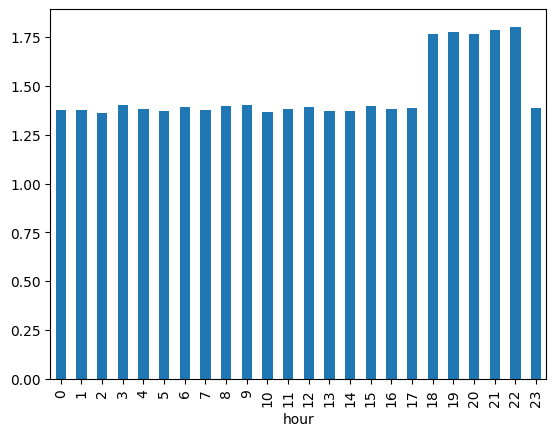

In [ ]:
df.groupby("hour")["kwh"].mean().plot(kind="bar")

In [38]:
daily = (
        df
        .groupby(['customer_id', 'region', 'tariff_plan', 'is_smart_meter', 'date', 'day_name'])
        .agg(
            daily_kwh=('kwh', 'sum'),
            daily_outage_minutes=('outage_minutes_last_24h', 'max'),
            daily_bill_eur=('bill_amount_eur', 'sum'),
            any_complaint=('complaint_flag', 'max')
        )
        .reset_index()
    )
daily['high_outage_day'] = (daily['daily_outage_minutes'] >= 30).astype(int)

daily.head()

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,0
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,0
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,0
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,0


In [40]:
# DAILY AGGREGATION FUNCTION
def aggregate_to_daily(df: pd.DataFrame) -> pd.DataFrame:
    daily = (
        df
        .groupby(['customer_id', 'region', 'tariff_plan', 'is_smart_meter', 'date', 'day_name'])
        .agg(
            daily_kwh=('kwh', 'sum'),
            daily_outage_minutes=('outage_minutes_last_24h', 'max'),
            daily_bill_eur=('bill_amount_eur', 'sum'),
            any_complaint=('complaint_flag', 'max')
        )
        .reset_index()
    )
    daily['high_outage_day'] = (daily['daily_outage_minutes'] >= 30).astype(int)
    return daily

In [41]:
daily = aggregate_to_daily(df)
daily.head()

,customer_id,region,tariff_plan,is_smart_meter,date,day_name,daily_kwh,daily_outage_minutes,daily_bill_eur,any_complaint,high_outage_day
0,201,East,fixed,1,2026-01-01,Thursday,40.674543,15,7.321418,0,0
1,201,East,fixed,1,2026-01-02,Friday,29.456769,16,5.302218,0,0
2,201,East,fixed,1,2026-01-03,Saturday,32.690122,15,5.884222,1,0
3,201,East,fixed,1,2026-01-04,Sunday,34.040236,13,6.127243,1,0
4,201,East,fixed,1,2026-01-05,Monday,31.587888,17,5.685820,1,0


In [42]:
daily.shape

(7338, 11)

<Axes: xlabel='day_name'>

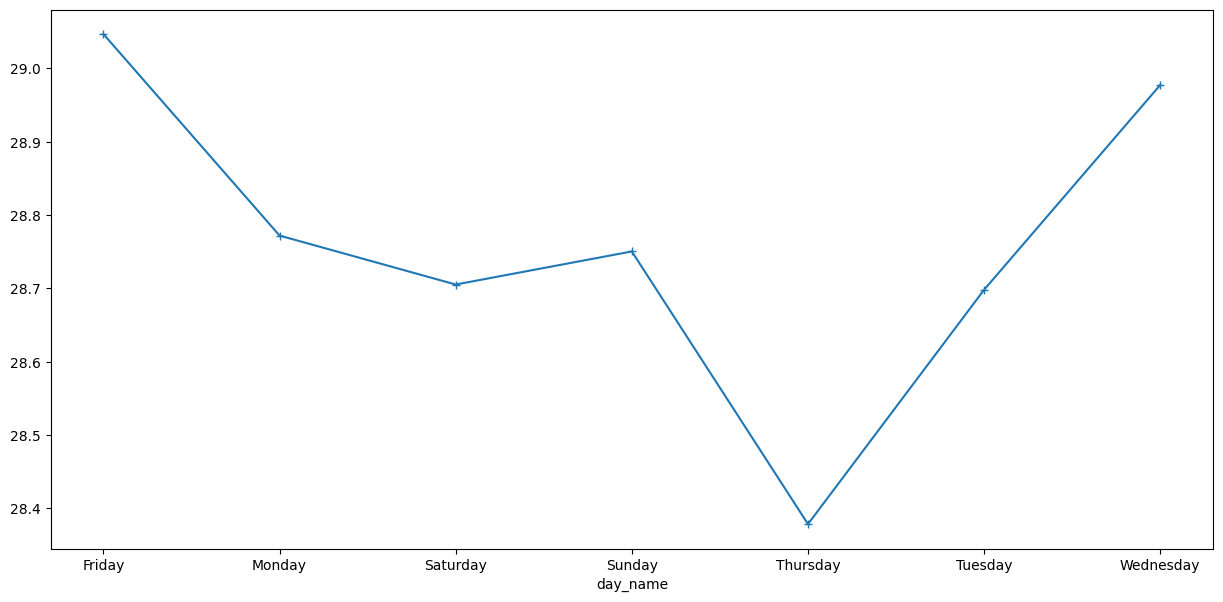

In [56]:
# PLOT AVERAGE DAILY KWH BY DAY OF WEEK USING LINE PLOT
daily.groupby("day_name")["daily_kwh"].mean().plot(kind="line", figsize=(15, 7), marker='+')

<Axes: >

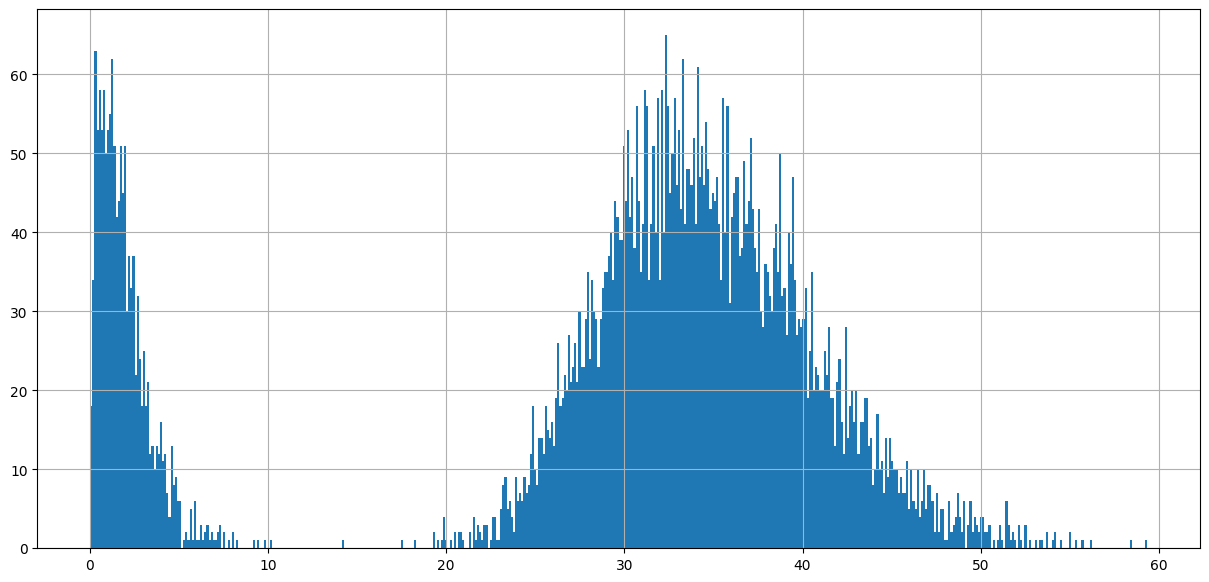

In [48]:
# PLOT DAILY_KWH DISTRIBUTION USING HISTOGRAM
daily["daily_kwh"].hist(bins=500, figsize=(15, 7))

<Axes: xlabel='day_name'>

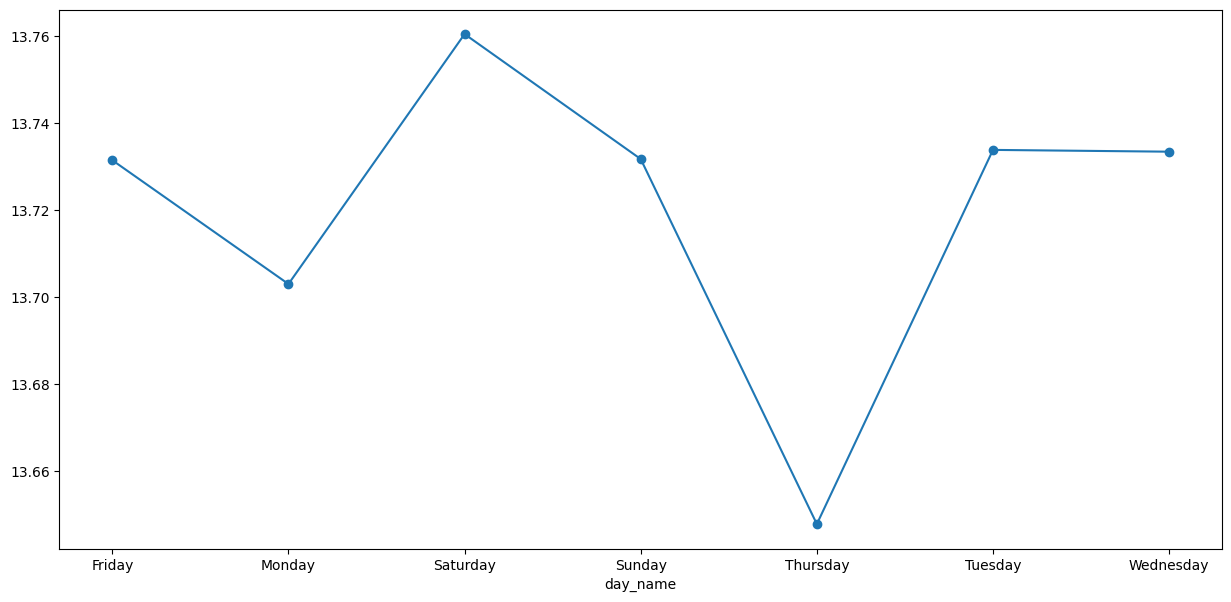

In [58]:
daily.groupby("day_name")["daily_outage_minutes"].mean().plot(kind="line", figsize=(15, 7), marker='o')

<Axes: xlabel='day_name'>

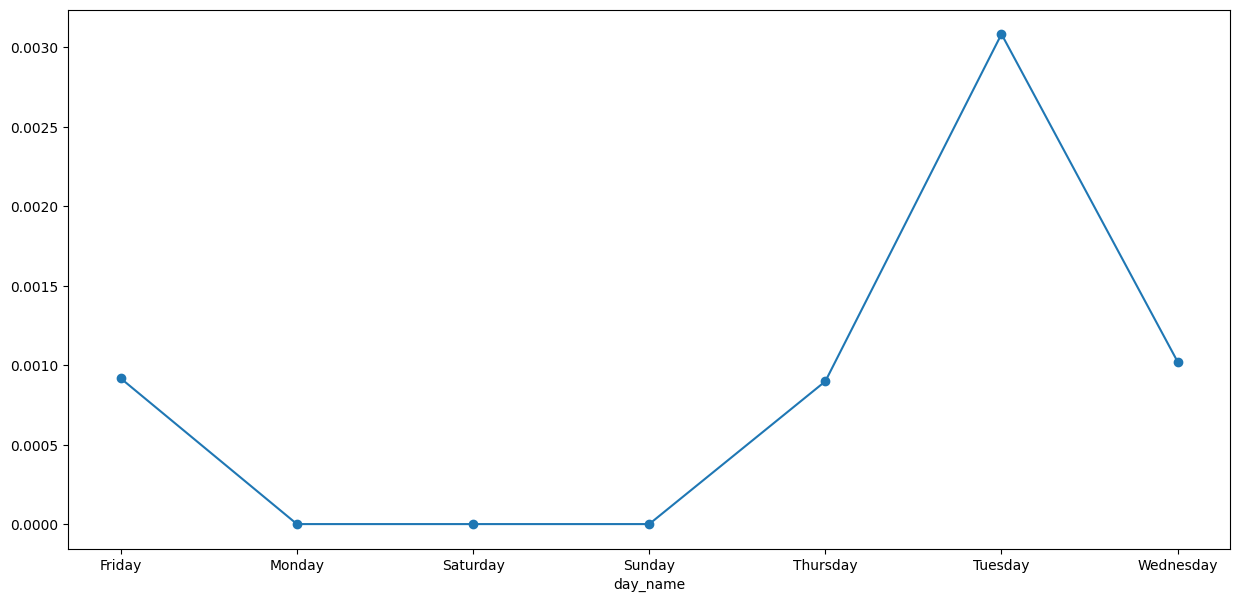

In [61]:
daily.groupby("day_name")["high_outage_day"].mean().plot(kind="line", figsize=(15, 7), marker='o')

###### SAVE FEATURE ENGINEERED DATA AND THE AGGREGATED DATA INTO DATA/FEATURE

In [62]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "engineered", "energy_engineered_data.csv")

os.makedirs(os.path.dirname(data_path), exist_ok=True)

df.to_csv(data_path, index=False)


BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(BASE_DIR, "data", "engineered", "energy_engineered_daily_aggregated_data.csv")

os.makedirs(os.path.dirname(data_path), exist_ok=True)

daily.to_csv(data_path, index=False)